In [1]:
from Aplha_n_methods import Alpha_N_calc as an
from Geometry_methods import Geometry_helper as gh

from scipy.optimize import curve_fit
import numpy as np
import openmc
import matplotlib.pyplot as plt


In [2]:
#Getting material 
mats = openmc.Materials.from_xml('materials.xml')

energy span 2000 8000
Waiting for SRModule to produce output...
end of file
[24.95964, 23.68794, 22.51652, 21.44533, 20.4743, 19.57341, 18.75263, 17.99194, 16.66078, 15.519832, 14.549045999999999, 13.688381999999999, 12.947814, 12.287322, 11.16651]
[2250000.0, 2500000.0, 2750000.0, 3000000.0, 3250000.0, 3500000.0, 3750000.0, 4000000.0, 4500000.0, 5000000.0, 5500000.0, 6000000.0, 6500000.0, 7000000.0, 8000000.0]
[ 3.06811673e+07  3.00871170e-06 -1.08057118e+00]
[[ 2.00222422e+11 -2.80640790e-02 -4.95371394e+04]
 [-2.80640790e-02  3.98852148e-15  6.79979735e-09]
 [-4.95371394e+04  6.79979735e-09  1.26828088e-02]]


/tmp/ipykernel_3703/2213795082.py:12: RuntimeWarning: invalid value encountered in log
  return A*np.log(B*E)/E + C


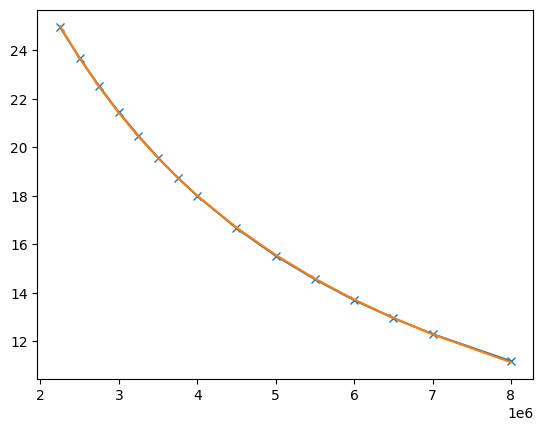

In [5]:
fuel_name= 'Fuel_A'
mat = gh.get_material_by_name(fuel_name,mats)
energies,stopping_powers = an.SR_file_write_and_read(mat,E_min=2000,E_max=8000,new_file=True)

fig,ax = plt.subplots()
ax.plot(energies,stopping_powers,'x-',label=fuel_name)
print(stopping_powers)
print(energies)

def bethe_tail(E, A, B, C):
    E=np.array(E)
    return A*np.log(B*E)/E + C

popt, cov = curve_fit(
    bethe_tail,
    energies, stopping_powers,
    p0=[50, 1, 0]
)

stopping_powers_fit = bethe_tail(energies, *popt)
ax.plot(energies,stopping_powers_fit,label='fit')
print(popt)
print(cov)

[]

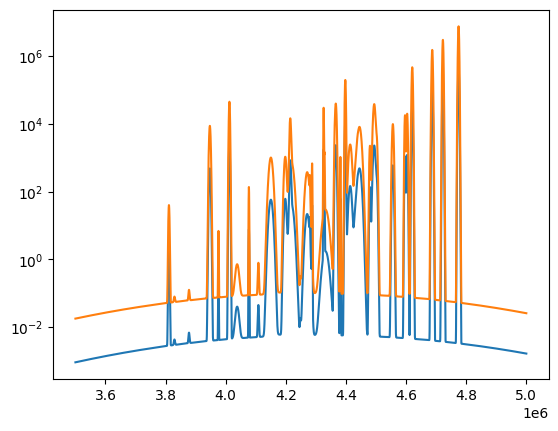

In [9]:
alpha_decays, mass = an.alpha_decay_values_from_material(mat)
alpha_spectra,energies = an.energy_spectra_gaussian(alpha_decays,x=None)
stopping_powers_fit = bethe_tail(energies, *popt)

fig, ax = plt.subplots()
ax.plot(energies,alpha_spectra/stopping_powers_fit)
ax.plot(energies,alpha_spectra)
ax.semilogy()


